<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
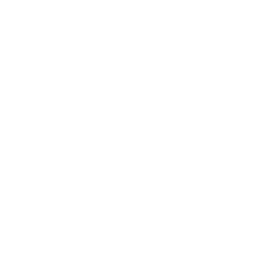
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Övervakning av valsningsprocessen vid stålverk</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Multivariat SPC för tjocklek och ytkvalitet i varmvalsverk &nbsp;|&nbsp; Mars 2026</p>
</div>
</div>
</div>

## Sammanfattning

Ett varmvalsverk valsar stålämnen till tunt band. Åtta korrelerade
processignaler (tjocklekar, valskraft, valsspalt, motorström,
utgångstemperatur) rör sig tillsammans när linjen är i normalt skick,
så att övervaka dem ett diagram i taget missar de gemensamma
förskjutningar som är viktiga. Detta exempel bygger en multivariat
baslinje med **PROC MVPMODEL** och strömmar sedan 100
produktionsspolar genom **PROC MVPMONITOR**, som poängsätter varje
spole med ett enda Hotellings *T*&sup2;-värde och jämför det med en
kontrollgräns.

Mot en kontrollgräns på *T*&sup2; = **17,13** (&alpha; = 0,05) signalerar
**4 av 100 spolar** utom kontroll — spolarna **91, 92, 94 och 95**,
precis det fönster där ett vibrationsutbrott i stödvalsen injicerades.
Toppvärdet *T*&sup2; når **21,91** vid spole 95, ungefär **1,3
gånger** gränsen. Den gradvisa ökningen av valsslitage över de senare
spolarna höjer baslinjens *T*&sup2;, men stannar under gränsen fram
till vibrationshändelsen, så diagrammet skiljer tydligt mellan
långsam drift och det akuta fel som kräver omedelbar uppmärksamhet.


## Datakällor

- **mill_baseline** &mdash; 50 spolar valsade under en känd, väl
  fungerande period av kampanjen; används för att anpassa den
  multivariata (PCA) referensmodellen.
- **mill_stream** &mdash; 100 spolar från den löpande linjen. Spolarna
  1&ndash;55 körs i kontroll; valsslitage utvecklas gradvis över
  spolarna 56&ndash;100; ett vibrationsutbrott i stödvalsen träffar
  spolarna 91&ndash;95.
- **Processvariabler** (6): `entry_thickness`, `exit_thickness`,
  `rolling_force`, `roll_gap`, `motor_current`, `exit_temp`.

> Miljön körs olicensierad, så datamängderna är begränsade till 100
> observationer. Scenariot är anpassat till den begränsningen: störningen
> placeras sent i en 100-spolars ström istället för vid spole 2 800 av
> 5 000.


---

### Steg 1 &mdash; Bygg den multivariata referensmodellen

`PROC MVPMODEL` utför en principalkomponentanalys av de sex
processvariablerna på den kontrollerade baslinjen och skriver
laddningar, egenvärden samt centrering/skalning till `mill_model`. Tre
komponenter behålls. Denna modell definierar hur "normalt" ser ut som
en enda multivariat region istället för sex oberoende intervall.


In [1]:
data mill_baseline;
  CALL streaminit(66);
  GÖR coil_id = 1 TILL 50;
    entry_thickness = 25.00 + rand('normal', 0, 0.30);
    exit_thickness  =  3.00 + rand('normal', 0, 0.030);
    rolling_force   = 18000 + rand('normal', 0, 150);
    roll_gap        =  2.85 + rand('normal', 0, 0.015);
    motor_current   =   850 + rand('normal', 0, 8);
    exit_temp       =   880 + rand('normal', 0, 4.0);
    UTDATA;
  SLUT;
KÖR;

PROC MVPMODEL data=mill_baseline outmodel=mill_model;
  VARIABEL entry_thickness exit_thickness rolling_force
      roll_gap motor_current exit_temp;
  ETIKETT entry_thickness="Ingångstjocklek (mm)"
        exit_thickness="Utgångstjocklek (mm)"
        rolling_force="Valskraft (N)"
        roll_gap="Valsspalt (mm)"
        motor_current="Motorström (A)"
        exit_temp="Utgångstemperatur (grader C)";
  ncomp=3;
KÖR;



                    The MVPMODEL Procedure

  Data Set:          mill_baseline
  Number of Variables: 6
  Missing Value Handling: Exclude
  Number of Observations Read: 50
  Number of Observations Used: 50
  Number of Principal Components: 3

  Correlation Matrix
         Ingångstjocklek (mm)Utgångstjocklek (mm)Valskraft (N)Valsspalt (mm)Motorström (A)Utgångstemperatur (grader C)
  Ingångstjocklek (mm)    1.0000   -0.0416   -0.1641   -0.1661    0.1555    0.0649
  Utgångstjocklek (mm)   -0.0416    1.0000    0.0406    0.0029    0.0946   -0.1421
  Valskraft (N)   -0.1641    0.0406    1.0000   -0.1351    0.2077   -0.0051
  Valsspalt (mm)   -0.1661    0.0029   -0.1351    1.0000   -0.0510   -0.0876
  Motorström (A)    0.1555    0.0946    0.2077   -0.0510    1.0000    0.1587
  Utgångstemperatur (grader C)    0.0649   -0.1421   -0.0051   -0.0876    0.1587    1.0000

  Eigenvalues of the Correlation Matrix
       Eigenvalue   Difference   Proportion  Cumulative
    1 1.37232115  0.14267284    


NOTE: DATA mill_baseline


NOTE: Wrote mill_baseline (50 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MVPMODEL
NOTE: PROC MVPMODEL statement used.


---

### Steg 2 &mdash; Strömma produktionsspolarna och poängsätt dem

`PROC MVPMONITOR` projicerar var och en av de 100 produktionsspolarna
på den sparade modellen och beräknar dess Hotellings *T*&sup2;.
Proceduren härleder kontrollgränsen från modellens dimensioner och
standardvärdet &alpha; = 0,05, och flaggar sedan varje spole vars
*T*&sup2; överskrider den. Resultaten, inklusive kolumnerna
`_TSQUARED`, `_LIMIT` och `_SIGNAL`, skrivs till `mill_scores` med
`coil_id` som nyckel.


In [2]:
data mill_stream;
  CALL streaminit(42);
  GÖR coil_id = 1 TILL 100;
    /* valsslitage ökar 0 -> 1 över spolarna 56-100 */
    wear    = MAX(0, coil_id - 55) / 45;
    /* vibrationsutbrott i stödvalsen på spolarna 91-95 */
    chatter = (coil_id >= 91 AND coil_id <= 95);
    entry_thickness = 25.00 + rand('normal', 0, 0.30);
    exit_thickness  =  3.00 + wear*0.10 + chatter*0.35
                            + rand('normal', 0, 0.030);
    rolling_force   = 18000 + wear*600  + chatter*1600
                            + rand('normal', 0, 150);
    roll_gap        =  2.85 + wear*0.055
                            + rand('normal', 0, 0.015);
    motor_current   =   850 + wear*38   + chatter*95
                            + rand('normal', 0, 8);
    exit_temp       =   880 + rand('normal', 0, 4.0);
    TA_BORT wear chatter;
    UTDATA;
  SLUT;
KÖR;

PROC MVPMONITOR data=mill_stream MODEL=mill_model
                out=mill_scores;
  VARIABEL entry_thickness exit_thickness rolling_force
      roll_gap motor_current exit_temp;
  ETIKETT entry_thickness="Ingångstjocklek (mm)"
        exit_thickness="Utgångstjocklek (mm)"
        rolling_force="Valskraft (N)"
        roll_gap="Valsspalt (mm)"
        motor_current="Motorström (A)"
        exit_temp="Utgångstemperatur (grader C)";
  id coil_id;
KÖR;



                    The MVPMONITOR Procedure

  Variables:       6
  Observations:    100
  T2 Limit:        17.1334
  Signals:         4
  Variables Monitored: Ingångstjocklek (mm), Utgångstjocklek (mm), Valskraft (N), Valsspalt (mm), Motorström (A), Utgångstemperatur (grader C)





NOTE: DATA mill_stream


NOTE: Wrote mill_stream (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MVPMONITOR
NOTE: PROC MVPMONITOR statement used.


Procedursammanfattningen redovisar kontrollgränsen och antalet
signaler. Nedan visar den utskrivna delen kring störningen att
baslinjespolarna ligger väl under gränsen medan
vibrationsfönstret driver fyra spolar över den.


In [3]:
/* Flagga spolar utom kontroll och spara larm-T2 för plottning */
data mill_scores;
  STÄLL_IN mill_scores;
  OM _SIGNAL = 1 SÅ t2_alarm = _TSQUARED;
  ANNARS t2_alarm = .;
KÖR;

PROC PRINT data=mill_scores(firstobs=88 obs=96) noobs;
  VARIABEL coil_id _TSQUARED _LIMIT _SIGNAL;
  ETIKETT coil_id="Spol-ID"
        _TSQUARED="T2-värde"
        _LIMIT="Kontrollgräns"
        _SIGNAL="Signal (0=i kontroll, 1=larm)";
  TITEL "T2-värden genom vibrationsfönstret (spolar 88-96)";
KÖR;


                                   T2-värden genom vibrationsfönstret (spolar 88-96)                                    

Spol-ID   T2-värde   Kontrollgräns  Signal (0=i kontroll, 1=larm)
     88   9.983151       17.133408                              0
     89   2.915646       17.133408                              0
     90    7.80613       17.133408                              0
     91  18.813814       17.133408                              1
     92  18.249361       17.133408                              1
     93  16.638221       17.133408                              0
     94  17.981792       17.133408                              1
     95  21.912329       17.133408                              1
     96   5.118574       17.133408                              0

... 4 more observations (showing 9 of 13)




NOTE: DATA mill_scores


NOTE: Read 100 rows from mill_scores.
NOTE: Wrote mill_scores (100 rows, 25 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds
NOTE: PROC PRINT data=mill_scores

NOTE: PROC PRINT completed: 9 observations printed, 4 variables


---

### Steg 3 &mdash; Multivariat styrdiagram

Diagrammet lägger den spolvisa *T*&sup2; ovanpå dess kontrollgräns.
Spolar utom kontroll markeras i rött; den streckade vertikala
markören anger starten på vibrationsutbrottet. Den långsamma
uppgången mot höger är valsslitage som höjer baslinjen; de fyra röda
punkterna är det akuta vibrationsfelet.


                                   T2-värden genom vibrationsfönstret (spolar 88-96)                                    




NOTE: PROC SGPLOT data=mill_scores

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


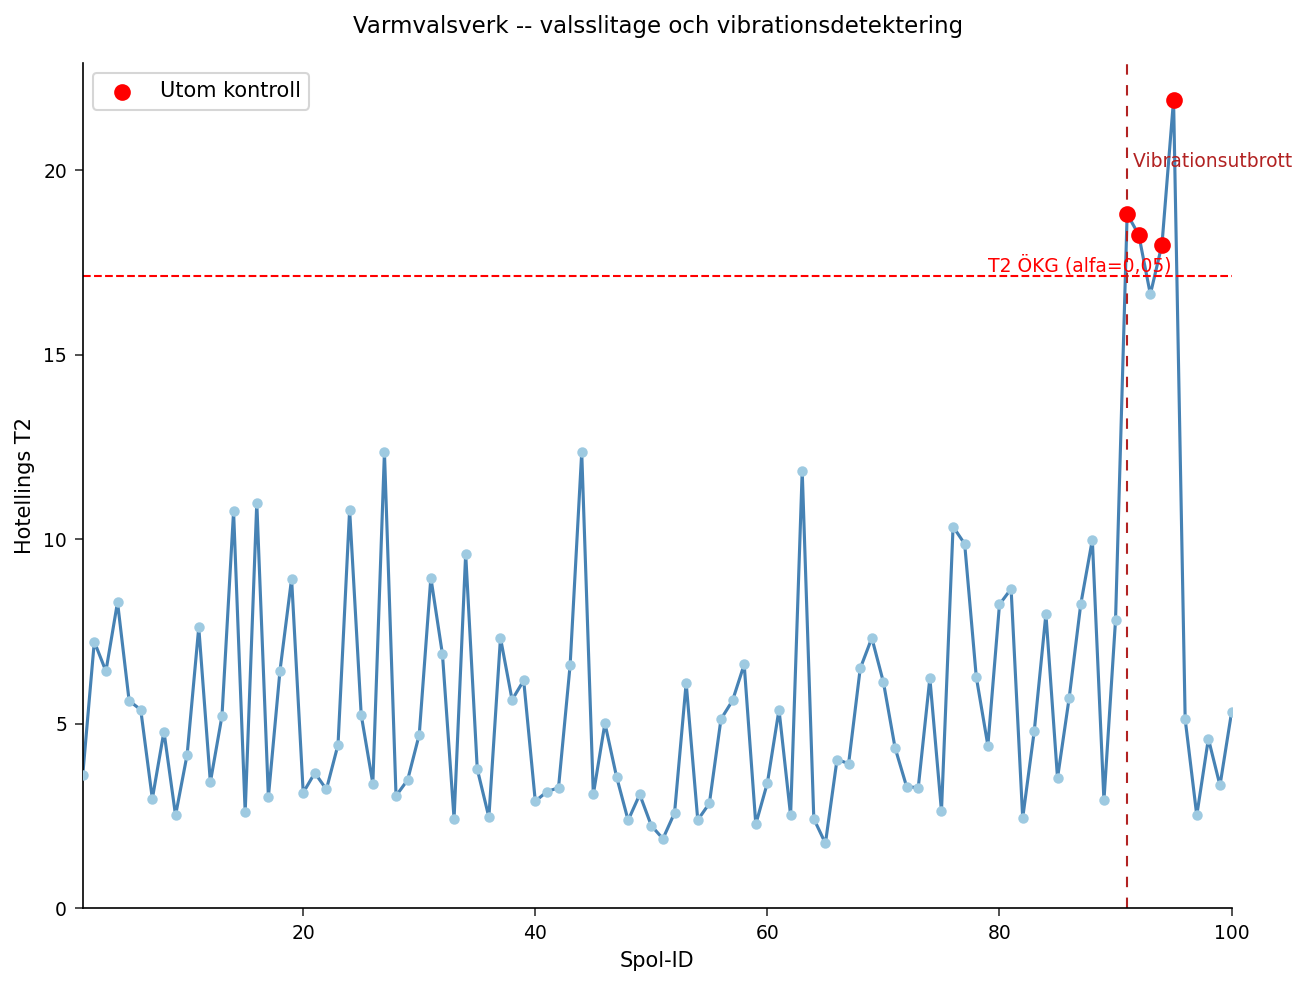

In [4]:
PROC SGPLOT data=mill_scores;
  SERIES  x=coil_id y=_TSQUARED /
          LINEATTRS=(color=steelblue thickness=1.5);
  SCATTER x=coil_id y=_TSQUARED /
          MARKERATTRS=(SYMBOL=circlefilled size=4 color=cx9ecae1);
  SCATTER x=coil_id y=t2_alarm /
          MARKERATTRS=(SYMBOL=circlefilled size=7 color=red)
          legendlabel="Utom kontroll";
  REFLINE _LIMIT / AXIS=y
          ETIKETT="T2 ÖKG (alfa=0,05)"
          LINEATTRS=(color=red pattern=dash);
  REFLINE 91 / AXIS=x ETIKETT="Vibrationsutbrott"
          LINEATTRS=(color=firebrick pattern=shortdash);
  XAXIS ETIKETT="Spol-ID" MIN=1 MAX=100;
  YAXIS ETIKETT="Hotellings T2" MIN=0;
  TITEL "Varmvalsverk -- valsslitage och vibrationsdetektering";
KÖR;


---

### Steg 4 &mdash; Kvantifiera spolarna utom kontroll

Spolarna utom kontroll dirigeras till en separat datamängd för
kvalitetsavdelningen. `PROC MEANS` jämför *T*&sup2;-nivån för de
flaggade spolarna mot populationen i kontroll, och de flaggade
spolarna exporteras för vidare hantering av skrot/omarbetning.


In [5]:
data mill_ooc;
  STÄLL_IN mill_scores;
  OM _SIGNAL = 1;
KÖR;

PROC MEANS data=mill_scores n mean MAX maxdec=2;
  KLASS _SIGNAL;
  VARIABEL _TSQUARED;
  ETIKETT _SIGNAL="Signal (0=i kontroll, 1=larm)"
        _TSQUARED="T2-värde";
  TITEL "T2 per kontrolltillstånd (0 = i kontroll, 1 = signal)";
KÖR;

PROC PRINT data=mill_ooc noobs;
  VARIABEL coil_id _TSQUARED _LIMIT;
  ETIKETT coil_id="Spol-ID"
        _TSQUARED="T2-värde"
        _LIMIT="Kontrollgräns";
  TITEL "Spolar utom kontroll flaggade för inspektion";
KÖR;

PROC EXPORT data=mill_ooc
            OUTFILE='steel_mill_ooc_coils.csv'
            DBMS=csv REPLACE;
KÖR;


                                 T2 per kontrolltillstånd (0 = i kontroll, 1 = signal)                                  

                                                  The MEANS Procedure

                                        Analysis Variable : _TSQUARED T2-värde

        Signal (0=i kontroll, 1=larm)          N Obs           Mean        Maximum
        --------------------------------------------------------------------------
        0                                         96           5.39          16.64
        1                                          4          19.24          21.91
        --------------------------------------------------------------------------

                                      Spolar utom kontroll flaggade för inspektion                                      

Spol-ID   T2-värde   Kontrollgräns
     91  18.813814       17.133408
     92  18.249361       17.133408
     94  17.981792       17.133408
     95  21.912329       17.133408




NOTE: DATA mill_ooc


NOTE: Read 100 rows from mill_scores.
NOTE: Wrote mill_ooc (4 rows, 25 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=mill_ooc

NOTE: PROC PRINT completed: 4 observations printed, 3 variables
NOTE: PROC EXPORT data=mill_ooc outfile=steel_mill_ooc_coils.csv

NOTE: Exported 4 rows to steel_mill_ooc_coils.csv.


## Resultat

- **Övervakade spolar**: 100; **kontrollgräns** *T*&sup2; = **17,13**
  (&alpha; = 0,05).
- **Spolar utom kontroll**: **4** &mdash; spolarna **91, 92, 94, 95**,
  alla inom det injicerade vibrationsfönstret (91&ndash;95). Spole 93
  toppar på *T*&sup2; = 16,64, precis under gränsen.
- **Toppallvarlighet**: *T*&sup2; = **21,91** vid spole 95 (ungefär
  1,3 gånger gränsen); spolarna i kontroll har ett medelvärde på
  *T*&sup2; &asymp; **5,4**.
- **Slitage kontra fel**: den gradvisa ökningen av valsslitage höjer
  baslinjen för de senare spolarna men korsar aldrig gränsen på egen
  hand, så det enda multivariata diagrammet skiljer långsam drift
  (bevaka) från det akuta vibrationsfelet (agera).
- **Åtgärd**: de fyra flaggade spolarna exporteras till
  `steel_mill_ooc_coils.csv` för inspektion och
  skrot-/omarbetningshantering; vibrationssignaturen pekar mot
  stödvalsens lager för inspektion före nästa kampanj.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>